# ¿Se puede ser robusto sin confiar en el modelo?

Hasta ahora usamos el modelo para *ayudar* al control.  
Pero… ¿qué pasa cuando el modelo es malo, incompleto o directamente incierto?

En esta notebook exploramos **robustez**:  
la capacidad de mantener un comportamiento aceptable **a pesar** de errores de modelo y perturbaciones externas.

---

## Ensayo propuesto

Compararemos dos estrategias:

- **Control PD+FF**
- **Control por Modos Deslizantes (Sliding Modes)**

sobre una misma planta, sometida a:

- carga adicional  
- errores en los parámetros dinámicos  
- perturbaciones (ruido de cuantización) 

La referencia será simple, para que el foco esté en el **comportamiento del control**, no en la trayectoria.

---

## Preguntas para guiar la observación

- ¿Cuál de los controles mantiene mejor el tracking cuando el modelo falla?
- ¿Qué ocurre con el esfuerzo de control?
- ¿Aparece *chattering*? ¿Por qué?
- ¿Cómo responde cada control al ruido de medición?

---

## Objetivo de la notebook

Entender que:

- **Robustez no es sinónimo de suavidad**
- El control discontinuo puede ser una **elección de diseño**, no un defecto
- Confiar menos en el modelo suele implicar pagar un precio en el actuador

El objetivo no es “elegir el mejor control”, sino **entender el compromiso**.


In [4]:
import numpy as np
import roboticstoolbox as rtb         # la funcionalidad específica de robótica está en el toolbox
import spatialmath as sm              # spatialmath tiene define los grupos de transformaciones especiales: rotación SO3 y eculideo SE3
import matplotlib.pyplot as plt
from tqdm import tqdm
plt.style.use('default')

In [114]:
# Preparo el modelo de un doble péndulo
dp = rtb.DHRobot(
    [
        rtb.RevoluteDH(a=200e-3,m=1.5,
                r=np.array([-100, 0, 0]) * 1e-3,
                I=np.array([0,0,0,0,0,0,0,0,1e-3]),
                B=0.1, G=1),
        rtb.RevoluteDH(a=200e-3,m=1,
                r=np.array([-100, 0, 0]) * 1e-3,
                I=np.array([0,0,0,0,0,0,0,0,1e-3]),
                B=0.1, G=1),
    ],
    gravity = np.array([0, -9.8, 0]), # Ojo con el signo, la gravedad va hacia abajo con signo positivo
    name = "DoblePendulo")

qr = np.array([-np.pi/2,0])
qz = np.zeros((2,))

print(dp)
print(dp.dynamics())

def plot_curves(t, q, qd, u, s=None, q_ref=None, qd_ref=None, idx=None):
    colores = plt.rcParams['axes.prop_cycle'].by_key()['color']        

    plt.figure(figsize=(8,6))
    plt.subplot(311)
    for i in range(q.shape[1]):
        color_eje = colores[i % len(colores)]
        plt.plot(t,q[:, i],color=color_eje,linestyle='-',linewidth=1,label=f'$q_{i+1}$')
        if q_ref is not None:
            plt.plot(t,q_ref[:, i],color=color_eje,linestyle='--',linewidth=1,label=f'$q_{i+1}^{{ref}}$')
    plt.legend(loc='upper right')
    plt.ylabel('$\dot{q}$ [rad]')
    plt.subplot(312)
    for i in range(q.shape[1]):
        color_eje = colores[i % len(colores)]
        plt.plot(t,qd[:, i],color=color_eje,linestyle='-',linewidth=1,label=f'$\dot{{q}}_{i+1}$')
        if q_ref is not None:
            plt.plot(t,qd_ref[:, i],color=color_eje,linestyle='--',linewidth=1,label=f'$\dot{{q}}_{i+1}^{{ref}}$')
    plt.ylabel(r'$\dot{q}$ [rad/s]')
    plt.legend(loc='upper right')
    plt.subplot(313)
    for i in range(u.shape[1]):
        plt.plot(t,u[:,i],linewidth=1,label=f'$u_{i+1}$')
    plt.legend(loc='upper right')
    plt.xlabel('t [s]')
    plt.ylabel('u [Nm]')
    plt.tight_layout()

    if s is not None:
        plt.figure(figsize=(8,4))
        plt.plot(t[1:],s[1:])
        plt.xlabel('t [s]')
        plt.ylabel('s [rad/s]')
        plt.tight_layout()

    if idx is not None:
        plt.figure(figsize=(8,4))
        plt.subplot(1,2,1)
        plt.plot(q[:idx,0],qd[:idx,0])
        plt.plot(q[idx:,0],qd[idx:,0])        
        plt.xlabel('$q_1$');plt.ylabel('$\dot{q}_1$')
        plt.subplot(1,2,2)
        plt.plot(q[:idx,1],qd[:idx,1])
        plt.plot(q[idx:,1],qd[idx:,1])        
        plt.xlabel('$q_2$');plt.ylabel('$\dot{q}_2$')
        if idx>0:
            plt.legend(['Reaching','Sliding'],loc='upper right')
        plt.tight_layout()
        
    plt.show()

DHRobot: DoblePendulo, 2 joints (RR), dynamics, standard DH parameters
┌─────┬────┬─────┬──────┐
│ θⱼ  │ dⱼ │ aⱼ  │  ⍺ⱼ  │
├─────┼────┼─────┼──────┤
│  q1 │  0 │ 0.2 │ 0.0° │
│  q2 │  0 │ 0.2 │ 0.0° │
└─────┴────┴─────┴──────┘

┌──┬──┐
└──┴──┘

┌───────┬──────┬──────────────┬────────────────────────────┬────┬──────┬────────┬────┐
│   j   │  m   │      r       │             I              │ Jm │  B   │   Tc   │ G  │
├───────┼──────┼──────────────┼────────────────────────────┼────┼──────┼────────┼────┤
│ link1 │  1.5 │ -0.1,  0,  0 │  0,  0,  0.001,  0,  0,  0 │  0 │  0.1 │  0,  0 │  1 │
│ link2 │  1   │ -0.1,  0,  0 │  0,  0,  0.001,  0,  0,  0 │  0 │  0.1 │  0,  0 │  1 │
└───────┴──────┴──────────────┴────────────────────────────┴────┴──────┴────────┴────┘

None


## SMC: Sliding Mode Controller

Desarrollamos el control por modos deslizantes a partir de una ley un controlador de estructura variable del estilo:

$$ u_{sw} = \begin{cases}  K \quad s<0 \\ -K \quad s>0 \end{cases} $$

El objetivo del control es llevar al sistema hacia una superficie en el espacio de fases donde pueda deslizarse hacia el target. Al definir la superficie, implícitamente se indica cómo es la dinámica del sistema desdeado pues se imponen restricciones a la evolución en el espacio de fases. 

En robótica se define la superficie de deslizamiento de manera que cada eje evolucione hacia el origen con una dinámica de primer orden. Es decir que se diseña el sistema resultante pensando como desacoplado

$$ s = \dot{q} + \lambda q$$

Cuando se cumple $s=0$, el sistema está en la superficie de deslizamiento y la dinámica resulta:

$$ \dot{q} = -\lambda q$$

Es decir que evoluciona como un sistema lineal de primer orden.
Como esta no es la dinámica verdadera del sistema, en el instante siguiente se intentará apartar de la superficie deslizante, pero la acción de control buscará devolverla a este lugar.

Si se aplica adicionalmente una acción de control $u_{eq}$ no lineal utilizando la dinámica inversa, no habrá una cancelación exacta pues normalmente se tienen incertidumbres en el modelo. Sin embargo esto ayudará al término de conmutación del control.

$$ u = u_{eq} + u_{sw}$$

Las incertidumbres en el modelado y las perturbaciones harán que el sistema se aparte de la superficie, pero $u_{sw}$ actuará rápidamente para volverlo a su lugar. Puede entenderse entonces al término de conmutación como un **plus de actuación** que se aplica para robustez


100%|██████████| 999/999 [00:07<00:00, 133.08it/s]


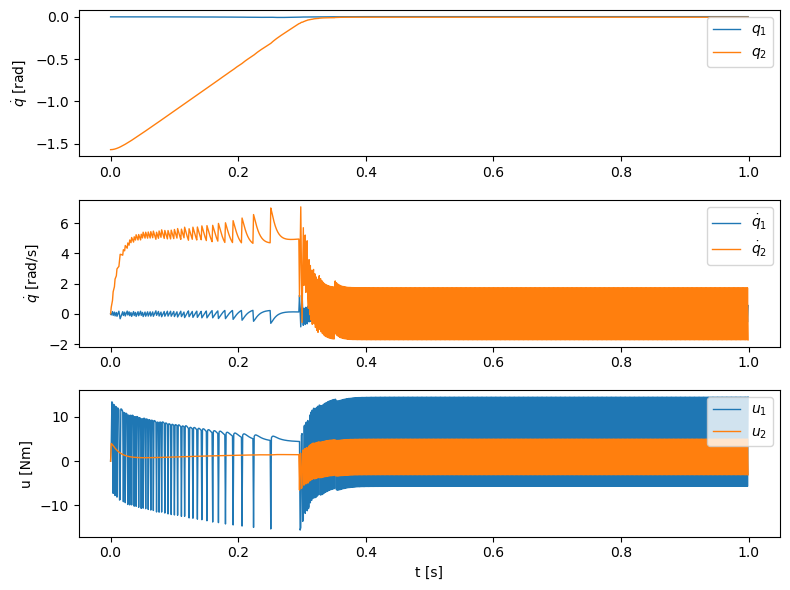

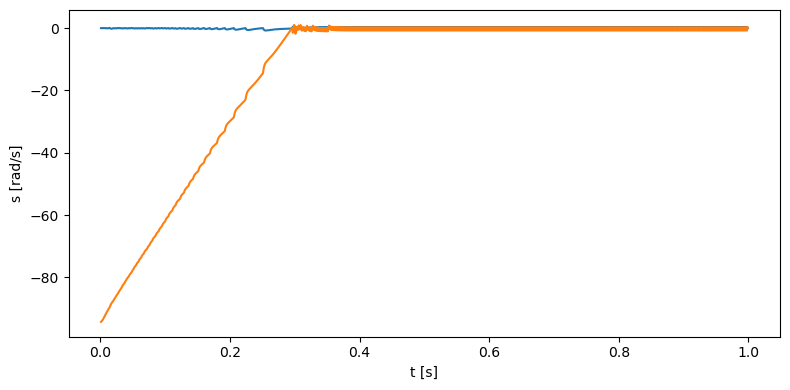

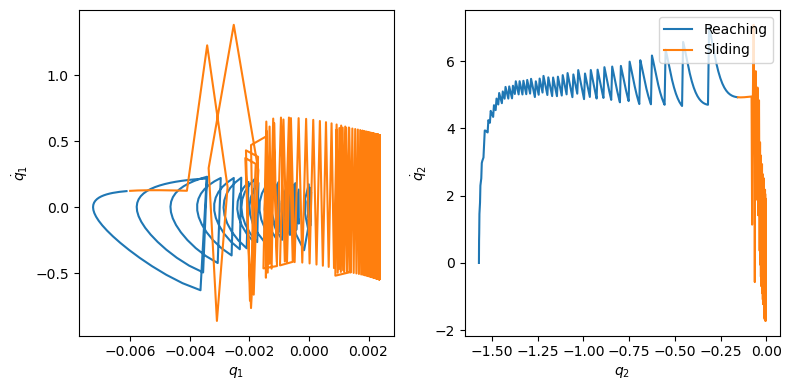

In [115]:
Tfin = 1
Ts = 1E-3
t = np.arange(0,Tfin,Ts)
Ns = len(t)

u = np.zeros((Ns,dp.n))
s = np.zeros_like(u)
q = np.zeros((Ns,dp.n))
qd = np.zeros((Ns,dp.n))
q[0] = np.r_[0,-np.pi/2]
qd_f = np.copy(qd)

# Ley de control SMC
def smc_controller(robot, t, q, qd,
                    Lambda=np.diag([60,60]), K=np.diag([10,4])):

    s  = qd + Lambda @ q

    M = robot.inertia(q)
    C = robot.coriolis(q, qd)
    G = robot.gravload(q)

    # Control equivalente (inverse dynamics)
    tau_eq = M @ ( -Lambda @ qd) + C @ (qd) + G

    # Término de conmutación 
    tau_sw = K @ np.sign(s)

    tau = tau_eq - tau_sw
    return tau,s

# Filtro de velocidad
ws = 2*np.pi/Ts
wf = ws/10
alpha = np.exp(-wf*Ts)

# Simulación
for idx in tqdm(range(1,Ns)):
  u[idx],s[idx] = smc_controller(dp,t[idx],q[idx-1],qd_f[idx-1])

  tg = dp.nofriction(coulomb=True,viscous=False).fdyn(Ts,q[idx-1],
                                                      Q=lambda *args, **kwargs: u[idx],
                                                      qd0=qd[idx-1],
                                                      progress=False)

  q[idx] = tg.q[-1]
  qd[idx] = tg.qd[-1]
  qd_f[idx] = alpha * qd_f[idx-1] + (1-alpha) * qd[idx]

plot_curves(t,q,qd,u,s,idx=280)


  0%|          | 0/999 [00:00<?, ?it/s]

100%|██████████| 999/999 [00:07<00:00, 137.29it/s]


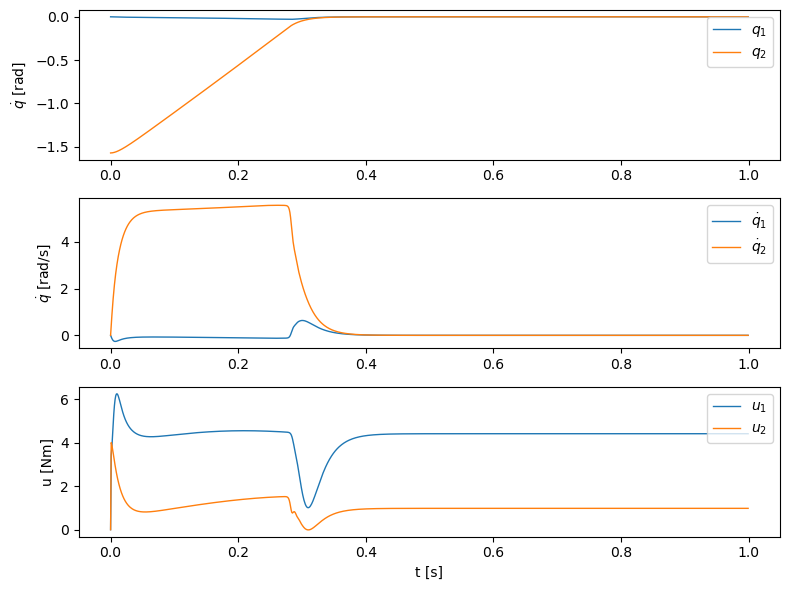

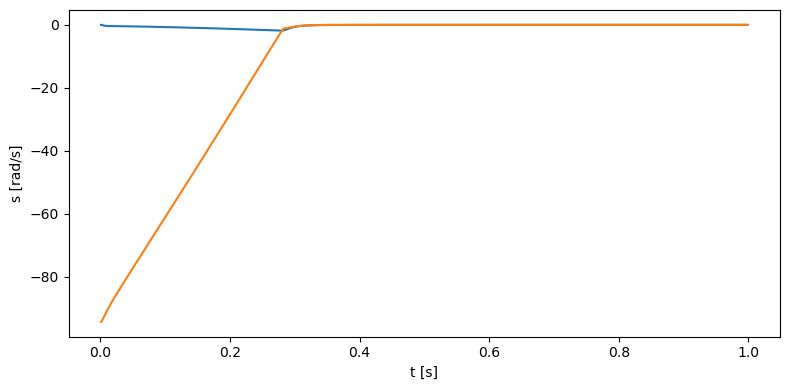

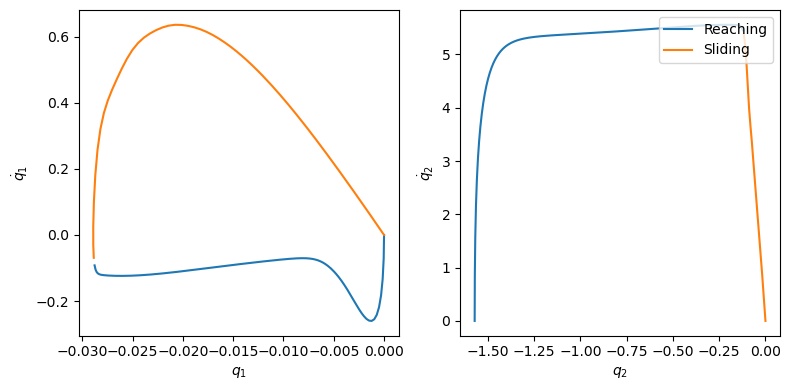

In [109]:
# Ajustamos la ley de control SMC para anular el chattering

# Ley de control SMC
def smc_controller(robot, t, q, qd,
                    Lambda=np.diag([60,60]), K=np.diag([10,4]),phi=1):

    s  = qd + Lambda @ q

    M = robot.inertia(q)
    C = robot.coriolis(q, qd)
    G = robot.gravload(q)

    # Control equivalente (inverse dynamics)
    tau_eq = M @ ( -Lambda @ qd) + C @ (qd) + G

    # Término de conmutación suavizado (tanh)
    tau_sw = K @ np.tanh(s / phi)

    tau = tau_eq - tau_sw
    return tau,s

# Filtro de velocidad
ws = 2*np.pi/Ts
wf = ws/10
alpha = np.exp(-wf*Ts)

# Simulación
for idx in tqdm(range(1,Ns)):
  u[idx],s[idx] = smc_controller(dp,t[idx],q[idx-1],qd_f[idx-1])

  tg = dp.nofriction(coulomb=True,viscous=False).fdyn(Ts,q[idx-1],
                                                      Q=lambda *args, **kwargs: u[idx],
                                                      qd0=qd[idx-1],
                                                      progress=False)

  q[idx] = tg.q[-1]
  qd[idx] = tg.qd[-1]
  qd_f[idx] = alpha * qd_f[idx-1] + (1-alpha) * qd[idx]

plot_curves(t,q,qd,u,s,idx=280)

# Seguimiento a trayectorias con incertidumbre en el modelo

In [116]:
# Perturbo la planta
dp_real = dp.perturb(0.1)
dp_real.payload(1)

# Genero una trayectoria joint con perfil trapezoidal
Ts=1E-3
t = np.arange(0, 1, Ts)
mst = rtb.mtraj( rtb.trapezoidal, np.r_[0,0], np.r_[np.pi/2,np.pi/4], t);
q_ref, qd_ref, qdd_ref = mst.q, mst.qd, mst.qdd

POSE_t_ref = dp.fkine(q_ref)

# Modelo del error de medición (considero un encoder de 4096 ppv)
e_med = (np.random.rand(len(q_ref))-0.5)/4096


100%|██████████| 999/999 [00:06<00:00, 152.18it/s]


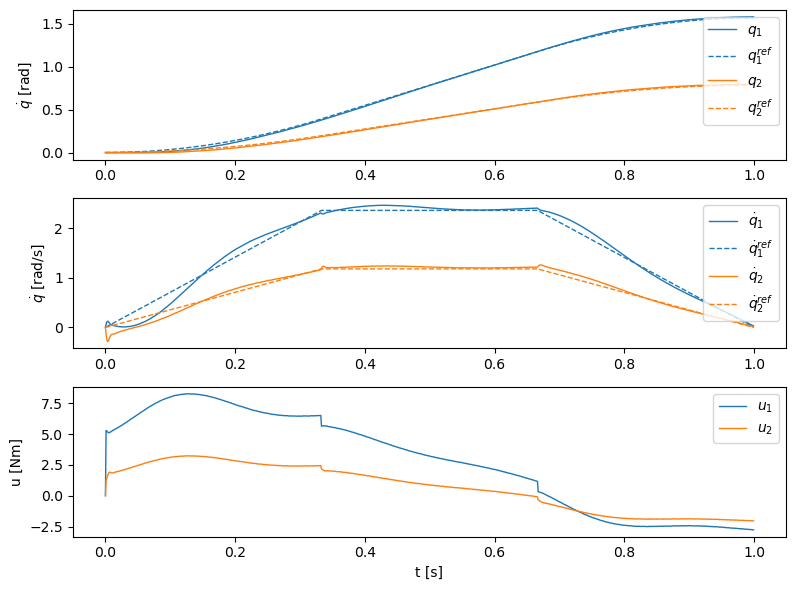

In [118]:
# Caso base a modo de comparación: control PD+FF
# Inicialización de vectores
u = np.zeros_like(q_ref)
s = np.zeros_like(q_ref)
q = np.zeros_like(q_ref)
qd = np.zeros_like(q_ref)
q[0] = q_ref[0]
qd_f = np.copy(qd)

# Ley de control PDFF
def pdff_controller(robot,t,q,qd,q_ref,qd_ref,qdd_ref):
  M = robot.inertia(q_ref)
  C = robot.coriolis(q_ref, qd_ref)
  G = robot.gravload(q_ref)
  # Notar que no compenso B: podríamos considerar que es un error de modelado :-)
  uff = M @ qdd_ref + C @ qd_ref + G

  Kp = 100*np.eye(2)
  Kd = 2*np.eye(2)
  ufb = Kp @ (q_ref-q) + Kd @ (qd_ref-qd)

  u = ufb + uff
  return u

# Filtro de velocidad
ws = 2*np.pi/Ts
wf = ws/10
alpha = np.exp(-wf*Ts)

q_real = q[0]
# Simulación
for idx in tqdm(range(1,Ns)):
  u[idx] = pdff_controller(dp,t[idx],q[idx-1],qd_f[idx-1],q_ref[idx],qd_ref[idx],qdd_ref[idx])
  tg = dp_real.nofriction(coulomb=True,viscous=False).fdyn(Ts,q_real,
                                                           Q=lambda *args, **kwargs: u[idx],
                                                           qd0=qd[idx-1],
                                                           progress=False)

  q_real = tg.q[-1]
  q[idx] = q_real + e_med[idx]
  qd[idx] = tg.qd[-1] 
  qd_f[idx] = alpha * qd_f[idx-1] + (1-alpha) * qd[idx]

e_pdff = q_ref-q
POSE_t_pdff = dp.fkine(q)

plot_curves(t,q,qd,u,q_ref=q_ref,qd_ref=qd_ref)


100%|██████████| 999/999 [00:06<00:00, 161.36it/s]


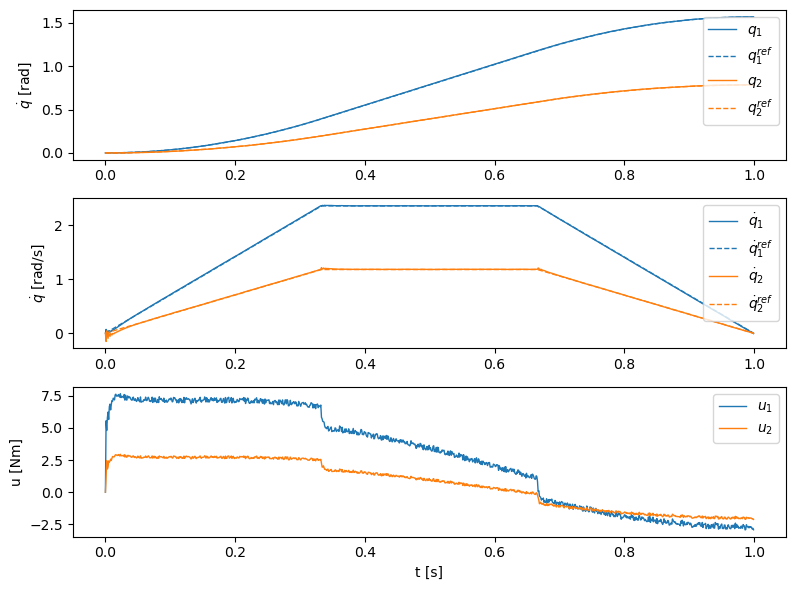

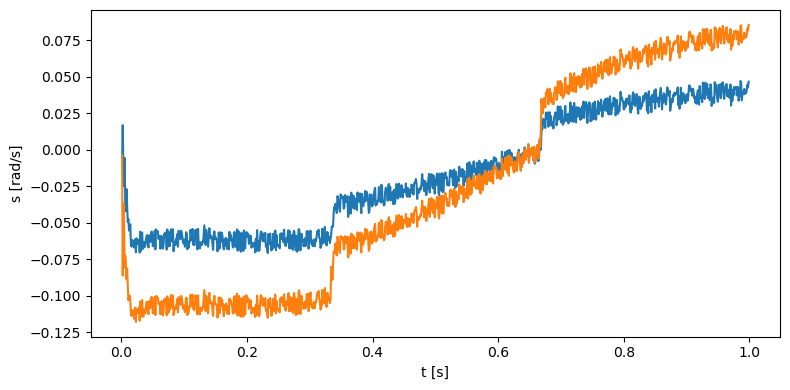

In [119]:
# Ley de control SMC
def smc_controller(robot, t, q, qd,
                   q_ref, qd_ref, qdd_ref, Lambda=np.diag([60,60]), K=1*np.diag([15,7]), phi=0.5):

    e  = q - q_ref
    ed = qd - qd_ref
    s  = ed + Lambda @ e

    M = robot.inertia(q)
    C = robot.coriolis(q, qd)
    G = robot.gravload(q)

    # Control equivalente (inverse dynamics)
    tau_eq = M @ (qdd_ref - Lambda @ ed) + C @ (qd_ref - Lambda @ e) + G

    # Término de conmutación suavizado (tanh)
    tau_sw = K @ np.tanh(s / phi)

    tau = tau_eq - tau_sw
    return tau, s

# Filtro de velocidad
ws = 2*np.pi/Ts
wf = ws/10
alpha = np.exp(-wf*Ts)

# Simulación
q_real = q[0]
for idx in tqdm(range(1,Ns)):
    u[idx],s[idx] = smc_controller(dp,t[idx],q[idx-1],qd_f[idx-1],q_ref[idx],qd_ref[idx],qdd_ref[idx])
    tg = dp_real.nofriction(coulomb=True,viscous=False).fdyn(Ts,q_real,
                                                             Q=lambda *args, **kwargs: u[idx],
                                                             qd0=qd[idx-1],
                                                             progress=False)

    q_real = tg.q[-1]
    q[idx] = q_real + e_med[idx]
    qd[idx] = tg.qd[-1] 
    qd_f[idx] = alpha * qd_f[idx-1] + (1-alpha) * qd[idx]

e_smc = q_ref-q
POSE_t_smc = dp.fkine(q)

plot_curves(t,q,qd,u,s,q_ref=q_ref,qd_ref=qd_ref)



# Comparación de resultados

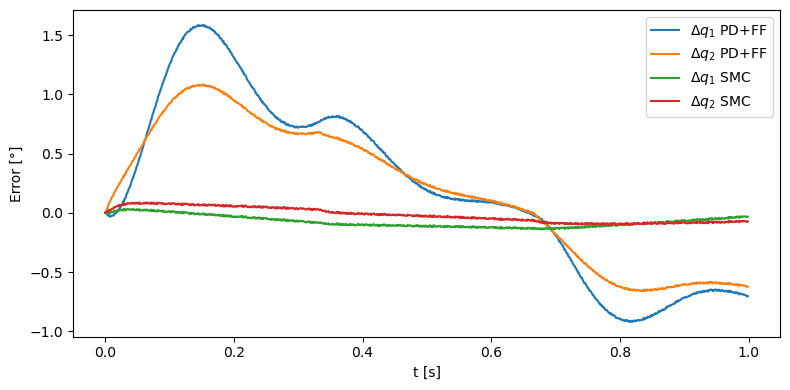

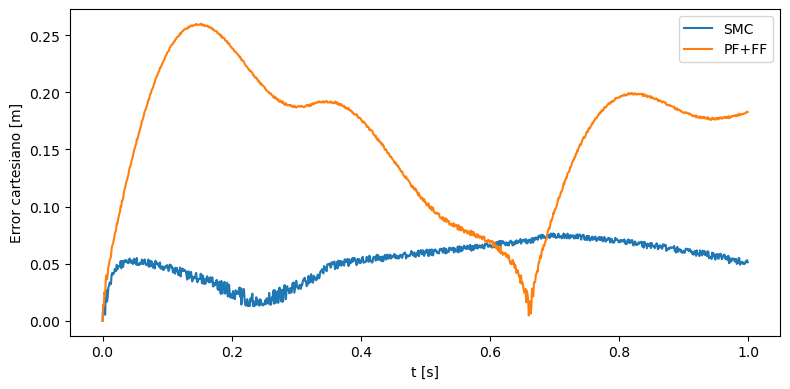

In [120]:
plt.figure(figsize=(8,4))
plt.plot(t,e_pdff*180/np.pi)
plt.plot(t,e_smc*180/np.pi)
plt.xlabel('t [s]')
plt.ylabel('Error [°]')
plt.legend(['$\Delta q_1$ PD+FF','$\Delta q_2$ PD+FF','$\Delta q_1$ SMC','$\Delta q_2$ SMC'],loc='upper right')
plt.tight_layout()
plt.show()

ec_pdff = np.zeros(len(POSE_t_ref))
ec_smc = np.zeros(len(POSE_t_ref))
for i in range(len(POSE_t_ref)):
    ec_pdff[i] = np.sqrt(np.linalg.norm(POSE_t_ref[i]-POSE_t_pdff[i]))
    ec_smc[i] = np.sqrt(np.linalg.norm(POSE_t_ref[i]-POSE_t_smc[i]))


plt.figure(figsize=(8,4))
plt.plot(t,ec_smc,label='SMC')   
plt.plot(t,ec_pdff,label='PF+FF')
plt.legend(loc='upper right')
plt.xlabel('t [s]')
plt.ylabel('Error cartesiano [m]')
plt.tight_layout()